## Truncated SVD versus DLR-PCG

This notebook tests out the similarity of using the rank-$r$ truncated SVD solution of $X = U_x \Sigma_x V_x^T$ versus obtaining it via the DLR-PCG scheme.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from fenics import Function, FunctionSpace, plot
from algorithms.dynamical_low_rank_pcg import DynamicalLowRankPCG
from algorithms.matrix_free_rsvd import MatrixFreeRSVD, get_approximate_W, tikhonov_solver

from utils.colors import C2, C3, C5, CMAP
from utils.mesh_utils import get_square_f, get_square_mesh, get_L_mesh
from utils.metrics import matrix_to_vec, vec_to_matrix, SpaceIndexing
from utils.exact_forward_operator import ExactForwardOperator, solve_explicit

SEED = 15

/home/elias/miniforge3/envs/fenics_env/lib/python3.9/site-packages/ufl/__init__.py:250: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Setting up problem I:  N_b=192, N=2401 (done)
Setting up problem II:  N_b=192, N=2401 (done)
Setting up problem III:  N_b=256, N=3496 (done)


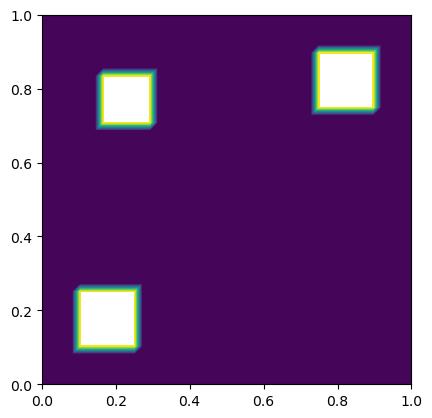

In [2]:
n = 48
d = .0
problem_params = {
    'I': {'mesh': get_square_mesh, 'n': n, 'width': 0.15, 'height': 0.15,
          'x0': [0.2], 'y0': [0.2]},
    'II': {'mesh': get_square_mesh, 'n': n, 'width': 0.15, 'height': 0.15,
           'x0': [0.1, 0.75, 0.15 + d], 'y0': [0.1, 0.75, 0.70 - d]},
    'III': {'mesh': get_L_mesh, 'n': n, 'width': 0.25, 'height': 0.25,
            'x0': [0.2, 1.55], 'y0': [0.2, 0.55]}
}

def get_source(V_h, x0_list, y0_list, width, height):
    x = np.zeros(V_h.dim())
    for x0, y0 in zip(x0_list, y0_list):
        f = get_square_f(V_h, x0=x0, y0=y0, w=width, h=height)
        x += f.vector().get_local()

    f = Function(V_h)
    f.vector()[:] = x
    return f, x


def problem_setup(params):
    # Function space setup
    mesh = params['mesh'](params['n'])
    V_h = FunctionSpace(mesh, 'CG', 1)
    rsvd = MatrixFreeRSVD(V_h)

    # Source setup
    f, x = get_source(
        V_h, params['x0'], params['y0'], 
        params['width'], params['height']
    )
    y = rsvd.apply_K(x)
    problem = {'V_h': V_h, 'rsvd': rsvd, 'f': f, 'x': x, 'y': y}
    return problem


def problems_setup(problem_params):
    problems =  {}
    for key, params in problem_params.items():
        print(f"Setting up problem {key}: ", end='')
        pb = problem_setup(params)
        print(f" N_b={pb['rsvd'].N_b}, N={pb['rsvd'].N} (done)")
        problems[key] = pb
    return problems


problems = problems_setup(problem_params)
plot(problems['II']['f']);

In [3]:
def plot_solutions(f_list, params, titles=None, figsize=(10, 3), nrows=None, ncols=None, cbar=True):
    width = params['width']
    height = params['height']
    x0s, y0s = params['x0'], params['y0']

    import matplotlib.patches as patches
    
    if titles is None:
        titles = ['' for _ in f_list]

    if nrows is None:
        nrows = 1

    if ncols is None:
        ncols = len(f_list)
        
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, constrained_layout=True)

    if (ncols + nrows) > 1:
        axes = axes.flatten()
    else:
        axes = [axes]
    
    for ax, fi, ti in zip(axes, f_list, titles):
        plt.sca(ax)
        p = plot(fi, cmap=CMAP) #, norm=norm)

        ax.set_title(ti)
        ax.set_xticks([])
        ax.set_yticks([])
        
        if cbar:
            fig.colorbar(p, ax=ax, format="%.2f", shrink=0.655)

        for x0, y0 in zip(x0s, y0s):
            square = patches.Rectangle(
                (x0, y0), width, height,
                edgecolor="white",
                facecolor="none"
            )
            ax.add_patch(square)

    plt.show()

In [4]:
pid = 'II'
p = problems[pid]
params = problem_params[pid]

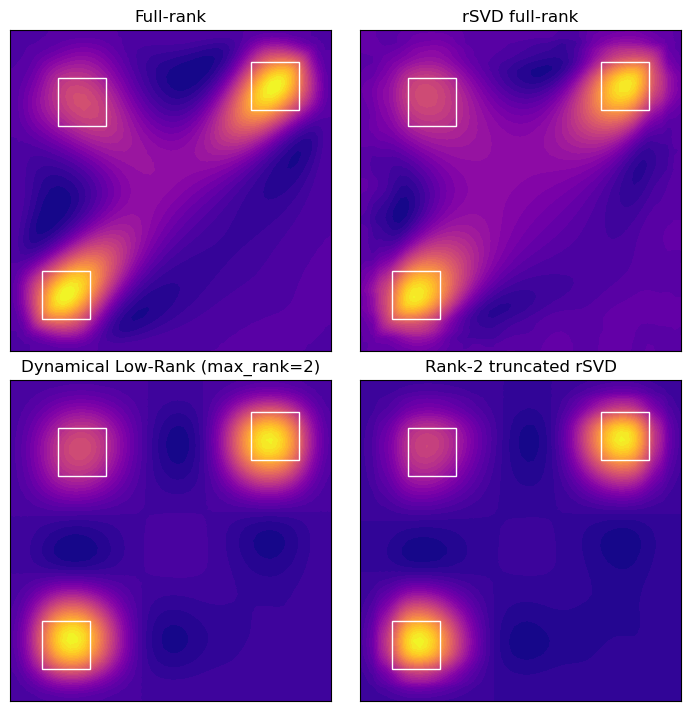

In [5]:
r = 2
lambda_ = 1e-4

# Full-rank solution
exact = ExactForwardOperator(p['V_h'])
f_fr = solve_explicit(exact, exact.get_weights(), p['y'], lambda_)

# Matrix-free rSVD
mfrsvd = MatrixFreeRSVD(p['V_h'])
mfrsvd.mf_rsvd(k=50)
w = get_approximate_W(mfrsvd.VkT.T, mfrsvd.M_dx)
x_hat = tikhonov_solver(mfrsvd, w, p['y'], lambda_=lambda_)
f_hat = Function(p['V_h'])
f_hat.vector()[:] = x_hat

# Truncated rSVD
index = SpaceIndexing(p['V_h'])
x_hat = f_hat.vector().get_local().copy()
X_hat = vec_to_matrix(x_hat, index)
U, S, Vt = np.linalg.svd(X_hat, full_matrices=False)
Ur, Sr, Vtr = U[:, :r], S[:r], Vt[:r, :]
X_r = Ur @ np.diag(Sr) @ Vtr
f_r = Function(p['V_h'])
f_r.vector()[:] = matrix_to_vec(X_r, index)

# Dynamical Low-Rank PCG
solver = DynamicalLowRankPCG(mfrsvd)
x_dlr = solver.solve(
    p['y'], w, preconditioner='ic',
    max_rank=r, lambda_=lambda_**2, verbose=False,
)
f_dlr = Function(p['V_h'])
f_dlr.vector()[:] = x_dlr

# Plot
f_list = [f_fr, f_hat, f_dlr, f_r]
titles = ['Full-rank', 'rSVD full-rank', f'Dynamical Low-Rank (max_rank={r})', f'Rank-{r} truncated rSVD']
params = problem_params['II']
plot_solutions(f_list, params, titles, figsize=(7, 7), nrows=2, ncols=2, cbar=False)